# Glove Sign Language — Bidirectional LSTM → TFLite → ESP32

**Pipeline:** CSV data → Sliding windows → Bi-LSTM model → TFLite → C header `.h`

**Features:** `flex1–5` (already min-max normalized 0–1) + `imu_x, imu_y, imu_z` (z-scored)

Place your CSV files in the same folder as this notebook before running.

In [1]:
# Install pyenv
brew install pyenv

# Install Python 3.11
pyenv install 3.11.9

# Set it locally for this project folder
pyenv local 3.11.9

# Verify
python --version

# Then install
pip install tensorflow numpy pandas matplotlib scikit-learn jupyter

SyntaxError: invalid syntax (1570517924.py, line 2)

In [ ]:
%pip install tensorflow numpy pandas matplotlib scikit-learn

  Using cached tensorflow-2.16.2-cp311-cp311-macosx_10_15_x86_64.whl.metadata (4.1 kB)
  Using cached numpy-2.4.5-cp311-cp311-macosx_14_0_x86_64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.3-cp311-cp311-macosx_10_9_x86_64.whl.metadata (79 kB)
  Using cached matplotlib-3.10.9-cp311-cp311-macosx_10_12_x86_64.whl.metadata (52 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached h5py-3.16.0-cp311-cp311-macosx_10_9_x86_64.whl.metadata (3.0 kB)
  Using cached libclang-18.1.1-py2.py3-none-macosx_10_9_x86_64.whl.metadata (5.2 kB)
  Using cached ml_dtypes-0.3.2-cp311-cp311-macosx_10_9_universal2.whl.metadata (20 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Usi

## 1. Imports

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, struct

import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow:", tf.__version__)

TensorFlow: 2.16.2


In [112]:
# ── Put your CSV filenames here ──────────────────────────────────────────────
CSV_FILES = [
    "pink8_1779075014.csv",
    "xinchao8_1779074640.csv",
    "pink8_1779075014.csv",
    "idle10_1779075315.csv",
    ""

    # add more CSVs as needed
]

# ── Window settings ──────────────────────────────────────────────────────────
Fs          = 30          # sampling rate (Hz)
WINDOW_SEC  = 1.0         # seconds per window
STRIDE_SEC  = 0.5         # stride in seconds (50 % overlap)

WINDOW_SIZE = 8   # 30 samples
STRIDE      = 4   # 15 samples

# ── Features ─────────────────────────────────────────────────────────────────
FLEX_COLS = ["flex1", "flex2", "flex3", "flex4", "flex5"]
IMU_COLS  = ["imu_x", "imu_y", "imu_z"]
FEATURE_COLS = FLEX_COLS + IMU_COLS   # 8 features total
LABEL_COL    = "SIGN"

# ── Training ──────────────────────────────────────────────────────────────────
TEST_SIZE   = 0.2
RANDOM_SEED = 42
EPOCHS      = 60
BATCH_SIZE  = 32

print(f"Window: {WINDOW_SIZE} samples ({WINDOW_SEC}s)  |  Stride: {STRIDE} samples")

Window: 8 samples (1.0s)  |  Stride: 4 samples


## 2. Config — edit here

In [214]:
# ── Put your CSV filenames here ──────────────────────────────────────────────
CSV_FILES = [
    "xinchao2_1778993189.csv",
    "pink5_1779077071.csv",
    "idle3_1779079022.csv",
    "C6_1779084422.csv"
    # add more CSVs as needed
]

# ── Window settings ──────────────────────────────────────────────────────────
Fs          = 30          # sampling rate (Hz)
WINDOW_SEC  = 1.0         # seconds per window
STRIDE_SEC  = 0.5         # stride in seconds (50 % overlap)

WINDOW_SIZE = 8   # 30 samples
STRIDE      = int(STRIDE_SEC * Fs)   # 15 samples

# ── Features ─────────────────────────────────────────────────────────────────
FLEX_COLS = ["flex1", "flex2", "flex3", "flex4", "flex5"]
IMU_COLS  = ["imu_x", "imu_y", "imu_z"]
FEATURE_COLS = FLEX_COLS + IMU_COLS   # 8 features total
LABEL_COL    = "SIGN"

# ── Training ──────────────────────────────────────────────────────────────────
TEST_SIZE   = 0.2
RANDOM_SEED = 42
EPOCHS      = 60
BATCH_SIZE  = 32

print(f"Window: {WINDOW_SIZE} samples ({WINDOW_SEC}s)  |  Stride: {STRIDE} samples")

Window: 8 samples (1.0s)  |  Stride: 15 samples


## 3. Load & merge CSVs

In [215]:
dfs = []
for f in CSV_FILES:
    df = pd.read_csv(f)
    dfs.append(df)
    print(f"{f}: {len(df)} rows  |  label='{df[LABEL_COL].iloc[0]}'")

raw = pd.concat(dfs, ignore_index=True)
print(f"\nTotal rows : {len(raw)}")
print("Class distribution:")
print(raw[LABEL_COL].value_counts())

xinchao2_1778993189.csv: 10039 rows  |  label='xinchao2'
pink5_1779077071.csv: 10081 rows  |  label='pink5'
idle3_1779079022.csv: 10068 rows  |  label='idle3'
C6_1779084422.csv: 6044 rows  |  label='C6'

Total rows : 36232
Class distribution:
SIGN
pink5       10081
idle3       10068
xinchao2    10039
C6           6044
Name: count, dtype: int64


## 4. Normalize IMU columns

Flex columns are already min-max scaled to [0, 1].  
IMU (Euler angles in degrees) gets z-scored using **training-set statistics** only.

In [216]:
# We compute IMU stats later (after train/test split) to avoid leakage.
# For now, extract the raw feature matrix and labels.
X_all = raw[FEATURE_COLS].values.astype(np.float32)  # (N, 8)
y_str = raw[LABEL_COL].values

le = LabelEncoder()
y_all = le.fit_transform(y_str)            # integer class indices
NUM_CLASSES = len(le.classes_)

print("Classes:", list(le.classes_))
print("Class indices:", list(range(NUM_CLASSES)))

Classes: ['C6', 'idle3', 'pink5', 'xinchao2']
Class indices: [0, 1, 2, 3]


## 5. Sliding-window segmentation

Each CSV is a continuous recording of one sign.  
We slide a window **per-class** so windows never cross class boundaries.

In [217]:
def make_windows(X, y, win, stride):
    """
    X : (N, F) float array
    y : (N,)   int array (same label per recording block)
    Returns X_win (M, win, F), y_win (M,)
    """
    Xw, yw = [], []
    # Process each class block separately
    # Find contiguous same-label runs
    changes = np.where(np.diff(y) != 0)[0] + 1
    starts  = np.concatenate([[0], changes])
    ends    = np.concatenate([changes, [len(y)]])

    for s, e in zip(starts, ends):
        block_X = X[s:e]
        block_y = y[s]       # single label for this block
        for i in range(0, len(block_X) - win + 1, stride):
            Xw.append(block_X[i : i + win])
            yw.append(block_y)

    return np.array(Xw, dtype=np.float32), np.array(yw, dtype=np.int32)


X_win, y_win = make_windows(X_all, y_all, WINDOW_SIZE, STRIDE)

print(f"Windows created : {X_win.shape}  → (num_windows, timesteps, features)")
print("Label distribution:")
unique, counts = np.unique(y_win, return_counts=True)
for cls, cnt in zip(le.classes_, counts):
    print(f"  {cls}: {cnt} windows")

Windows created : (2415, 8, 8)  → (num_windows, timesteps, features)
Label distribution:
  C6: 403 windows
  idle3: 671 windows
  pink5: 672 windows
  xinchao2: 669 windows


## 6. Train / Test split  +  IMU normalization (no leakage)

In [218]:
X_train, X_test, y_train, y_test = train_test_split(
    X_win, y_win,
    test_size   = TEST_SIZE,
    random_state= RANDOM_SEED,
    stratify    = y_win
)

# ── Z-score IMU from training set only ───────────────────────────────────────
# flex columns (0:5) are already in [0,1], leave them alone.
# IMU columns (5:8) need standardizing.
imu_slice = slice(5, 8)

IMU_MEAN = X_train[:, :, imu_slice].mean()   # global scalar
IMU_STD  = X_train[:, :, imu_slice].std()

X_train[:, :, imu_slice] = (X_train[:, :, imu_slice] - IMU_MEAN) / (IMU_STD + 1e-8)
X_test [:, :, imu_slice] = (X_test [:, :, imu_slice] - IMU_MEAN) / (IMU_STD + 1e-8)

print(f"Train: {X_train.shape}   Test: {X_test.shape}")
print(f"IMU_MEAN = {IMU_MEAN:.4f}   IMU_STD = {IMU_STD:.4f}")
print("\n** Write down IMU_MEAN and IMU_STD — needed in the ESP32 firmware **")

Train: (1932, 8, 8)   Test: (483, 8, 8)
IMU_MEAN = 59.1850   IMU_STD = 115.2362

** Write down IMU_MEAN and IMU_STD — needed in the ESP32 firmware **


## 7. Build the Bidirectional LSTM model

In [82]:
from tensorflow.keras import layers, models

def build_lstm(timesteps, features, num_classes):

    inp = layers.Input(shape=(timesteps, features))

    x = layers.LSTM(
        4,

        # IMPORTANT FIXES
        return_sequences=False,
        unroll=True
    )(inp)

    x = layers.Dropout(0.2)(x)

    x = layers.Dense(
        4,
        activation="relu"
    )(x)

    out = layers.Dense(
        num_classes,
        activation="softmax"
    )(x)

    model = models.Model(inp, out)

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


model = build_lstm(
    WINDOW_SIZE,
    len(FEATURE_COLS),
    NUM_CLASSES
)

model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 8, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 4)              │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │            20 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248 (992.00 B)

 Trainable params: 248 (992.00 B)

 Non-trainable params: 0 (0.00 B)

7.1 BUILD DENSE MODEL

In [219]:
from tensorflow.keras import layers, models

def build_dense(
    timesteps,
    features,
    num_classes
):

    inp = layers.Input(
        shape=(timesteps, features)
    )

    # Flatten time dimension
    x = layers.Flatten()(inp)

    # Tiny Dense Layers
    x = layers.Dense(
        16,
        activation="relu"
    )(x)

    x = layers.Dropout(0.2)(x)

    x = layers.Dense(
        8,
        activation="relu"
    )(x)

    out = layers.Dense(
        num_classes,
        activation="softmax"
    )(x)

    model = models.Model(inp, out)

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


model = build_dense(
    WINDOW_SIZE,
    len(FEATURE_COLS),
    NUM_CLASSES
)

model.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 8, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,212 (4.73 KB)

 Trainable params: 1,212 (4.73 KB)

 Non-trainable params: 0 (0.00 B)

7.1 1DCNN

In [131]:
from tensorflow.keras import layers, models

def build_cnn(
    timesteps,
    features,
    num_classes
):

    inp = layers.Input(
        shape=(timesteps, features)
    )

    x = layers.Conv1D(
        8,
        kernel_size=3,
        activation='relu',
        padding='same'
    )(inp)

    x = layers.MaxPooling1D(
        pool_size=2
    )(x)

    x = layers.Conv1D(
        16,
        kernel_size=3,
        activation='relu',
        padding='same'
    )(x)

    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(
        8,
        activation='relu'
    )(x)

    out = layers.Dense(
        num_classes,
        activation='softmax'
    )(x)

    model = models.Model(inp, out)

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


model = build_cnn(
    WINDOW_SIZE,
    len(FEATURE_COLS),
    NUM_CLASSES
)

model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 8, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 8, 8)           │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 4, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 4, 16)          │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 5)              │            45 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 781 (3.05 KB)

 Trainable params: 781 (3.05 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Train

In [220]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=15, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=7, min_lr=1e-5, verbose=1
    ),
]

history = model.fit(
    X_train, y_train,
    validation_data = (X_test, y_test),
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    callbacks       = callbacks,
)

Epoch 1/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2883 - loss: 1.3744 - val_accuracy: 0.5466 - val_loss: 1.2755 - learning_rate: 0.0010
Epoch 2/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5140 - loss: 1.2405 - val_accuracy: 0.7764 - val_loss: 1.1254 - learning_rate: 0.0010
Epoch 3/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6278 - loss: 1.0526 - val_accuracy: 0.7888 - val_loss: 0.8952 - learning_rate: 0.0010
Epoch 4/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6957 - loss: 0.8757 - val_accuracy: 0.9420 - val_loss: 0.6966 - learning_rate: 0.0010
Epoch 5/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7759 - loss: 0.7219 - val_accuracy: 0.9545 - val_loss: 0.5463 - learning_rate: 0.0010
Epoch 6/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8007 - loss: 0.6056 - val_accuracy: 0.9524 - val_loss: 0.4268 - learning_rate: 0.0010
Epoch 7/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8354 - loss: 0.5275 - val_accuracy: 

## 9. Evaluate

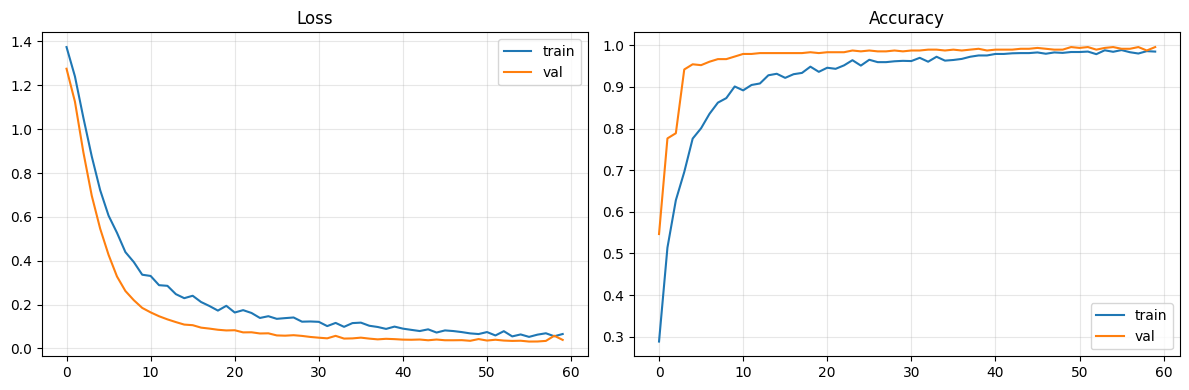

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
              precision    recall  f1-score   support

          C6       0.99      1.00      0.99        81
       idle3       0.99      0.99      0.99       134
       pink5       1.00      0.99      1.00       134
    xinchao2       1.00      1.00      1.00       134

    accuracy                           1.00       483
   macro avg       1.00      1.00      1.00       483
weighted avg       1.00      1.00      1.00       483



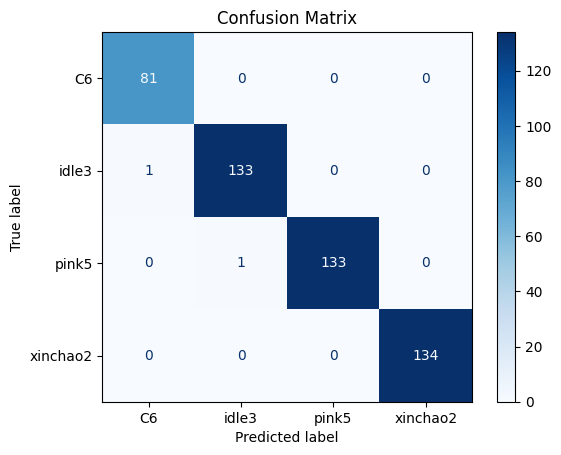

In [221]:
# ── Loss & accuracy curves ────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["loss"],     label="train")
ax1.plot(history.history["val_loss"], label="val")
ax1.set_title("Loss"); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history.history["accuracy"],     label="train")
ax2.plot(history.history["val_accuracy"], label="val")
ax2.set_title("Accuracy"); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120)
plt.show()

# ── Classification report ─────────────────────────────────────────────────────
y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=le.classes_))

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=120)
plt.show()

## 10. Convert to TFLite (INT8 quantized)

In [222]:
import tensorflow as tf
import os


def tflite_to_c_array(tflite_data, header_path, array_name):

    hex_array = [f"0x{b:02x}" for b in tflite_data]

    with open(header_path, "w") as f:

        f.write("// Auto-generated — do not edit manually\n\n")
        f.write("#pragma once\n")
        f.write("#include <stdint.h>\n\n")

        # Metadata
        f.write("// ===== MODEL METADATA =====\n")
        f.write(f"// Window Size : {WINDOW_SIZE}\n")
        f.write(f"// Features    : {len(FEATURE_COLS)}\n")
        f.write(f"// Classes     : {list(le.classes_)}\n\n")

        # Normalization constants
        f.write("// ===== NORMALIZATION =====\n")
        f.write(f"static const float IMU_MEAN = {IMU_MEAN:.6f}f;\n")
        f.write(f"static const float IMU_STD  = {IMU_STD:.6f}f;\n\n")

        # Labels
        labels = ", ".join(f'"{c}"' for c in le.classes_)
        f.write("// ===== LABELS =====\n")
        f.write(f"static const char* const SIGN_LABELS[] = {{{labels}}};\n")
        f.write(f"static const int NUM_CLASSES = {NUM_CLASSES};\n\n")

        # Model bytes
        f.write("// ===== TFLITE MODEL =====\n")
        f.write(f"const unsigned char {array_name}[] = {{\n  ")

        for i, h in enumerate(hex_array):
            f.write(h + ", ")

            if (i + 1) % 12 == 0:
                f.write("\n  ")

        f.write("\n};\n\n")

        f.write(
            f"const unsigned int {array_name}_len = {len(tflite_data)};\n"
        )


def export_glove_model(model, name="lstm"):

    base = "data_phuc"

    saved_dir   = os.path.join(base, f"glove_{name}_savedmodel")
    tflite_path = os.path.join(base, f"glove_{name}.tflite")
    header_path = os.path.join(base, "glove_model.h")

    # IMPORTANT:
    # Match your ESP32 variable name
    array_name = "glove_model_data"

    # Save model
    model.export(saved_dir)

    # ===== TFLITE CONVERSION =====
    converter = tf.lite.TFLiteConverter.from_saved_model(saved_dir)

    # IMPORTANT:
    # ONLY builtin ops allowed for ESP32
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS
    ]

    # Disable optimizations for compatibility
    converter.optimizations = []

    # Keep float32 model
    converter.inference_input_type  = tf.float32
    converter.inference_output_type = tf.float32

    # Convert
    tflite_model = converter.convert()

    # ===== VALIDATE MODEL =====
    interpreter = tf.lite.Interpreter(
        model_content=tflite_model
    )

    interpreter.allocate_tensors()

    print("✅ TFLite model validated successfully!")

    # Save .tflite
    with open(tflite_path, "wb") as f:
        f.write(tflite_model)

    print(
        f"✅ TFLite saved: {tflite_path} "
        f"({len(tflite_model)/1024:.1f} KB)"
    )

    # Export header
    tflite_to_c_array(
        tflite_model,
        header_path,
        array_name
    )

    print(f"✅ Header saved: {header_path}")
    print("✅ Copy glove_model.h into ESP32 project folder")


# RUN EXPORT
export_glove_model(model)

INFO:tensorflow:Assets written to: data_phuc/glove_lstm_savedmodel/assets


INFO:tensorflow:Assets written to: data_phuc/glove_lstm_savedmodel/assets


Saved artifact at 'data_phuc/glove_lstm_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 8, 8), dtype=tf.float32, name='keras_tensor_92')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  5446364400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5446361056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5446365280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5446367392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5446363344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5446364048: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1779085091.854495 1790361 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1779085091.854513 1790361 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.


✅ TFLite model validated successfully!
✅ TFLite saved: data_phuc/glove_lstm.tflite (7.9 KB)
✅ Header saved: data_phuc/glove_model.h
✅ Copy glove_model.h into ESP32 project folder


2026-05-18 13:18:11.854715: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: data_phuc/glove_lstm_savedmodel
2026-05-18 13:18:11.856368: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-18 13:18:11.856393: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: data_phuc/glove_lstm_savedmodel
2026-05-18 13:18:11.869321: I tensorflow/cc/saved_model/loader.cc:234] Restoring SavedModel bundle.
2026-05-18 13:18:11.915845: I tensorflow/cc/saved_model/loader.cc:218] Running initialization op on SavedModel bundle at path: data_phuc/glove_lstm_savedmodel
2026-05-18 13:18:11.929748: I tensorflow/cc/saved_model/loader.cc:317] SavedModel load for tags { serve }; Status: success: OK. Took 75025 microseconds.


In [223]:
print("Converting model to TFLite format...")

# 1. Define a concrete, static input function signature (Batch size = 1)
run_model = tf.function(lambda x: model(x))
concrete_func = run_model.get_concrete_function(
    tf.TensorSpec([1, WINDOW_SIZE, len(FEATURE_COLS)], model.inputs[0].dtype)
)

# 2. Build the converter pointing directly to the concrete function
converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete_func])

# 3. Configure flags to unpack and lower the Bi-LSTM loops safely
converter.experimental_enable_resource_variables = True
converter._experimental_lower_tensor_list_ops = False
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS, # Standard TFLite ops
    tf.lite.OpsSet.SELECT_TF_OPS    # Fallback to standard TF ops if needed for Bi-LSTM loops
]

# 4. Run the conversion
try:
    tflite_model = converter.convert()
    
    # Save the file
    tflite_model_path = "glove_bilstm.tflite"
    with open(tflite_model_path, "wb") as f:
        f.write(tflite_model)
        
    print(f"🎉 Success! TFLite model exported successfully to: {tflite_model_path}")
    print(f"Model Size: {len(tflite_model) / 1024:.2f} KB")
except Exception as e:
    print("\n❌ Conversion failed!")
    print("Error Details:", str(e))

Converting model to TFLite format...
🎉 Success! TFLite model exported successfully to: glove_bilstm.tflite
Model Size: 6.81 KB


2026-05-18 13:18:16.515031: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
2026-05-18 13:18:16.515211: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
W0000 00:00:1779085096.571981 1790361 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1779085096.571996 1790361 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2026-05-18 13:18:16.586040: I tensorflow/compiler/mlir/lite/flatbuffer_export.cc:3064] Estimated count of arithmetic ops: 2652  ops, equivalently 1326  MACs


## 11. Verify TFLite output matches Keras

In [224]:
# =========================================================
# 11. Verify TFLite output matches Keras
# =========================================================

import numpy as np
import tensorflow as tf

# Load exported model
with open("data_phuc/glove_lstm.tflite", "rb") as f:
    tflite_model = f.read()

# Create interpreter
interp = tf.lite.Interpreter(
    model_content=tflite_model
)

interp.allocate_tensors()

# Input / output tensors
in_idx  = interp.get_input_details()[0]["index"]
out_idx = interp.get_output_details()[0]["index"]

# Test a few samples
n_check = min(20, len(X_test))

match = 0

for i in range(n_check):

    sample = X_test[i:i+1].astype(np.float32)

    # TFLite inference
    interp.set_tensor(in_idx, sample)
    interp.invoke()

    tflite_pred = np.argmax(
        interp.get_tensor(out_idx)
    )

    # Keras inference
    keras_pred = np.argmax(
        model.predict(sample, verbose=0)
    )

    if tflite_pred == keras_pred:
        match += 1

print(
    f"TFLite vs Keras match: "
    f"{match}/{n_check} "
    f"({100*match/n_check:.1f}%)"
)

TFLite vs Keras match: 20/20 (100.0%)


## 12. Generate C header file for ESP32

In [225]:
# =========================================================
# 12. Generate C header file for ESP32
# =========================================================

HEADER_FILE = "glove_model2.h"

array_name = "glove_model_data"

# Read exported tflite
with open("data_phuc/glove_lstm.tflite", "rb") as f:
    tflite_model = f.read()

# Convert bytes -> hex array
hex_bytes = ", ".join(
    f"0x{b:02x}" for b in tflite_model
)

header_content = f"""
// Auto-generated by glove_bilstm_train.ipynb
// DO NOT EDIT MANUALLY

#pragma once
#include <stdint.h>

// ===== MODEL METADATA =====

// Window size
#define WINDOW_SIZE {WINDOW_SIZE}

// Number of features
#define NUM_FEATURES {len(FEATURE_COLS)}

// Number of classes
#define NUM_CLASSES {NUM_CLASSES}

// IMU normalization
static const float IMU_MEAN = {IMU_MEAN:.6f}f;
static const float IMU_STD  = {IMU_STD:.6f}f;

// Labels
static const char* const SIGN_LABELS[] = {{
    {", ".join(f'"{c}"' for c in le.classes_)}
}};

// ===== MODEL DATA =====

const unsigned char {array_name}[] = {{
{hex_bytes}
}};

const unsigned int {array_name}_len =
{len(tflite_model)};
"""

with open(HEADER_FILE, "w") as f:
    f.write(header_content)

print(f"✅ Header saved: {HEADER_FILE}")

print(
    f"Array size : "
    f"{len(tflite_model)} bytes "
    f"({len(tflite_model)/1024:.1f} KB)"
)

print(
    "✅ Copy glove_model.h into "
    "your ESP32 project"
)

✅ Header saved: glove_model2.h
Array size : 8072 bytes (7.9 KB)
✅ Copy glove_model.h into your ESP32 project


## 13. Print ESP32 inference snippet

This is a reference for your `main.cpp` — shows how to call the model.

In [124]:
# =========================================================
# 13. Print ESP32 inference snippet
# =========================================================

snippet = r '''
// ======================================================
// ESP32 TensorFlow Lite Micro Inference Example
// ======================================================

#include "glove_model.h"

#include "tensorflow/lite/micro/micro_mutable_op_resolver.h"
#include "tensorflow/lite/micro/micro_interpreter.h"
#include "tensorflow/lite/schema/schema_generated.h"

// ======================================================
// Tensor Arena
// ======================================================

constexpr int kTensorArenaSize = 120 * 1024;

alignas(16)
uint8_t tensor_arena[kTensorArenaSize];

// ======================================================
// TFLite Variables
// ======================================================

const tflite::Model* model = nullptr;

tflite::MicroInterpreter* interpreter = nullptr;

TfLiteTensor* input_tensor  = nullptr;
TfLiteTensor* output_tensor = nullptr;

// ======================================================
// Setup
// ======================================================

void setup() {

    Serial.begin(115200);

    Serial.println("Loading model...");

    model = tflite::GetModel(glove_model_data);

    if (model->version() != TFLITE_SCHEMA_VERSION) {

        Serial.println("Schema mismatch!");
        while (1);
    }

    // Resolver
    static tflite::MicroMutableOpResolver<5> resolver;

    resolver.AddFullyConnected();
    resolver.AddSoftmax();
    resolver.AddUnidirectionalSequenceLSTM();
    resolver.AddLogistic();
    resolver.AddReshape();

    // Interpreter
    static tflite::MicroInterpreter static_interpreter(
        model,
        resolver,
        tensor_arena,
        kTensorArenaSize
    );

    interpreter = &static_interpreter;

    Serial.println("Allocating tensors...");

    if (interpreter->AllocateTensors() != kTfLiteOk) {

        Serial.println("Tensor allocation failed!");
        while (1);
    }

    Serial.println("Tensor allocation OK!");

    input_tensor  = interpreter->input(0);
    output_tensor = interpreter->output(0);
}

// ======================================================
// Loop
// ======================================================

void loop() {

    // Example:
    // Fill 30x8 input tensor

    for (int i = 0; i < 30 * 8; i++) {

        input_tensor->data.f[i] = 0.0f;
    }

    // Run inference
    if (interpreter->Invoke() == kTfLiteOk) {

        int best_idx = 0;
        float best_score = 0;

        for (int i = 0; i < NUM_CLASSES; i++) {

            float score =
                output_tensor->data.f[i];

            if (score > best_score) {

                best_score = score;
                best_idx = i;
            }
        }

        Serial.print("Prediction: ");
        Serial.println(
            SIGN_LABELS[best_idx]
        );

        Serial.print("Confidence: ");
        Serial.println(best_score);
    }

    delay(1000);
}

'''

print(snippet)

SyntaxError: invalid syntax (3952375035.py, line 5)

## 14. Summary

Files generated:
- `glove_bilstm.keras` — full Keras model
- `glove_bilstm.tflite` — quantized TFLite model
- `glove_model.h` — C header for ESP32
- `training_curves.png` — loss & accuracy plots
- `confusion_matrix.png` — test set confusion matrix

**Next steps:**
1. Copy `glove_model.h` into your PlatformIO `src/` folder.
2. In `main.cpp`, collect `WINDOW_SIZE` frames into a ring buffer.
3. Normalize IMU values using the constants in the header.
4. Run `interpreter->Invoke()` and read the argmax of the output tensor.